# Analysis — N Particles

In [1]:
import matplotlib.pyplot as plt
import numpy as np
np.seterr('warn')

from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, get_xf_yf_fund, get_mean_amp_and_phase, get_fft

## Configuração
Edite apenas esta célula para adicionar/remover partículas ou frequências.

In [2]:
# filenames_all = fetch_data_filenames("./20-05-26")
filenames_all = fetch_data_filenames("./26-05-26_27-05-26")

In [3]:
# filenames_all = fetch_data_filenames("./23-05-26")
exc_data_npy = [
    extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all 
    if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("amp_offset_laser" in data_path_npy)
    ]

In [4]:
freq_list = sorted(set([dic["freq"] for dic in exc_data_npy]))

# Layout dos subplots de verificação visual
cols = 4
rows = int(np.ceil(len(freq_list) / cols))
    

## Análise — loop sobre N partículas

In [14]:
def time_domain_visual_verification(particles: list):

    for p_idx, p_dic in enumerate(particles):
        particle_label = f"Particle {p_dic['p_label']}"
        # correct = adj_phase_correction[p_idx] if p_idx < len(adj_phase_correction) else False

        print(f"\n{'='*50}")
        print(f"  Processing particle {p_dic['p_label']}  ")
        print(f"{'='*50}")

        omegas      = []
        phase_diffs = []

        # ---- Subplots de verificação visual ----
        fig, axs = plt.subplots(rows, cols, figsize=(12, 12), constrained_layout=True)
        fig.suptitle(f"Particle {p_dic["p_label"]}", fontsize=14)

        # data = p_dic["p_data"]

        for index, step_data in enumerate(p_dic["p_data"]):
            freq = step_data["freq"]
            i, j = divmod(index, cols)
            omega = 2 * np.pi * float(freq) * 1e-6
            omegas.append(omega)

            # Colocar para fazer calcular fases média

            ax = axs[i, j]
            for idx_rep, rep in enumerate(step_data["data"]):
                ax.plot(rep[:,0], rep[:,1])

            ax.set_title(f"{freq} Hz")


        plt.show()

# time_domain_visual_verification([{"p_label": 1, "p_data": exc_data_npy }])

## Get mean phases and errors

In [6]:
# #Calculate list of phasors for the laser and all measurements
# for step in exc_data_npy:
#   freq = step["freq"]
#   step["fft_amp_list"] = []
#   for meas_idx, meas in enumerate(step["data"]):
#     _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
#     step["fft_amp_list"].append(amp)

# # Get mean phase and error for each particle and each step (freq) 
# for step in exc_data_npy:
#     freq = step["freq"]
#     amp_list = step["fft_amp_list"]
#     _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
#     step["mean_fft_info"] = [freq, phase, phase_error]

# #Calculate list of phasors for all particles and all measurements
# for p in p_list:
#   for step in p["p_data"]:
#     freq = step["freq"]
#     step["fft_amp_list"] = []
#     for meas_idx, meas in enumerate(step["data"]):
#       _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
#       step["fft_amp_list"].append(amp)

# # Get mean phase and error for each particle and each step (freq) 
# for p in p_list:
#     for step in p["p_data"]:
#         freq = step["freq"]
#         amp_list = step["fft_amp_list"]
#         _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
#         step["mean_fft_info"] = [freq, phase, phase_error]

## Comparison — all particles

In [7]:
def get_error_bar(exc_data, p_list):
    exc_mean_phase = np.array([
            step["mean_fft_info"]
            #[freq, phase, phase_error]
            for step in exc_data
        ])
    error_exc = exc_mean_phase[:,2]
    # print(error_exc)

    for p in p_list:
        # if p["p_label"] !=1: continue
        p_mean_phase = np.array([
            step["mean_fft_info"]
            for step in p["p_data"]
            ])
        
        if (p_mean_phase[:,0]-exc_mean_phase[:,0]).sum() != 0.:
            print("Deu ruim!")
            return None
        else:
            pd_list = np.unwrap(p_mean_phase[:,1]-exc_mean_phase[:,1])
            pd_error = np.hypot(
                p_mean_phase[:,2],
                exc_mean_phase[:,2]
            )

        p["error_bar"] = np.column_stack((p_mean_phase[:,0], pd_list, pd_error))

# get_error_bar(exc_data_npy, p_list)

In [8]:
def plot_phase_difference(particles: list, p_to_skip = [], freqs_to_skip = []):
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for p_id, p in enumerate(particles):
        if p["p_label"] in p_to_skip: continue
        color = colors[p_id % len(colors)]
        # p["error_bar"]
        label_added = False
        for idx, error_point in enumerate(p["error_bar"]):
            # Skip frequencies larger than 20kHz
            if (error_point[0] in freqs_to_skip): 
                # print(f"Não foi calculado pra freq: {error_point[0]}Hz")
                continue
            
            current_label = f"Particle {p['p_label']}" if not label_added else None

            plt.errorbar(
                error_point[0],
                error_point[1],
                yerr=error_point[2],
                label=current_label,
                fmt='o',
                capsize=5,
                color=color,
            )
            label_added = True
        # plt.title(f"Particle {p['p_label']}  - phase difference")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Phase diferrence (rad)")
        plt.xscale("log")
    
    if len(particles)>1:
        plt_title = f"{len(particles)} Particles - phase difference" 
    else:
        plt_title = f"{len(particles)} Particle - phase difference" 

    plt.title(plt_title)
    plt.legend()
    plt.show()

# plot_phase_difference(p_list, p_to_skip=[], freqs_to_skip=[])

## Harmonic distortion by 2nd harmonic

freq: 1000, amp: 0.5, offset: 0.4


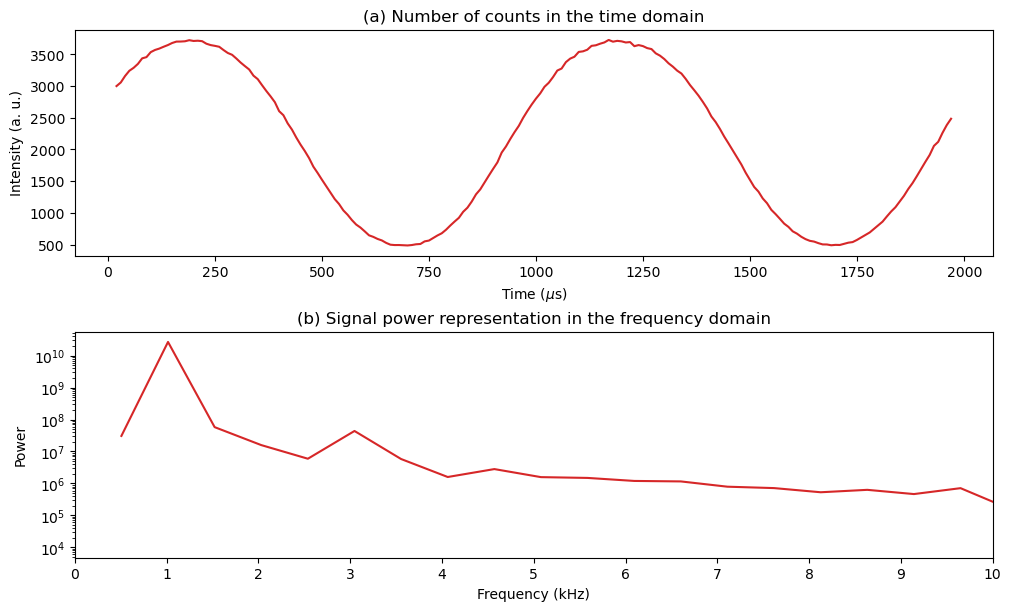

In [22]:
def plot_time_and_freq_domain(time, curve1, label1 = "lum", color1 = "tab:green" , 
                              curve2 = None, label2 = "laser", color2 = "tab:red"):
    """Plot time and frequency domain of the luminescence and laser curves"""
    # Suponho que a função get_fft já esteja definida no seu código
    xf_lum, yf_lum = get_fft(time, curve1)
    
    # Filtering only positive frequencies
    lum_mask = xf_lum > 0
    xf_lum = xf_lum[lum_mask]
    yf_lum = yf_lum[lum_mask]

    if curve2:
        xf_laser, yf_laser = get_fft(time, curve2)
        laser_mask = xf_laser > 0
        xf_laser = xf_laser[laser_mask]
        yf_laser = yf_laser[laser_mask]

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    # --- DOMÍNIO DO TEMPO ---
    # Eixo principal (Esquerdo - Verde/Lum)
    axs[0].set_xlabel("Time ($\mu$s)")
    line1 = axs[0].plot(time, curve1, color=color1, label=color1)
    axs[0].tick_params(axis='y', labelcolor="black" if (not curve2) else color1)
    axs[0].set_ylabel("Intensity (a. u.)", color="black" if (not curve2) else color1)
    axs[0].set_title("(a) Number of counts in the time domain")

    if curve2:
        # Eixo secundário (Direito - Vermelho/Laser)
        ax0_twin = axs[0].twinx()
        ax0_twin.set_ylabel("Intensity 2 (a.u.)", color=color2)
        line2 = ax0_twin.plot(time, curve2, color=color2, label=label2)
        ax0_twin.tick_params(axis='y', labelcolor=color2)

        # Juntando as legendas dos dois eixos
        lines_time = line1 + line2
        labels_time = [l.get_label() for l in lines_time]
        axs[0].legend(lines_time, labels_time, loc="best")


    # --- DOMÍNIO DA FREQUÊNCIA ---
    # Eixo principal (Esquerdo - Verde/Lum)
    axs[1].set_xlabel("Frequency (kHz)")
    line3 = axs[1].plot(.001*xf_lum, np.abs(yf_lum)**2, color=color1, label=label1)
    axs[1].tick_params(axis='y', labelcolor= "black" if (not curve2) else color1)
    axs[1].set_ylabel("Power", color="black" if (not curve2) else color1)
    axs[1].set_title("(b) Signal power representation in the frequency domain")
    axs[1].set_yscale("log")
    xticks = [i*1 for i in range(0, 11)]
    axs[1].set_xticks(xticks)
    axs[1].set_xlim(0, xticks[-1])

    if curve2:
        # Eixo secundário (Direito - Vermelho/Laser)
        ax1_twin = axs[1].twinx()
        ax1_twin.set_ylabel("Laser Power", color="tab:red")
        ax1_twin.set_yscale("log")
        line4 = ax1_twin.plot(xf_laser, np.abs(yf_laser)**2, color="tab:red", label="laser")
        ax1_twin.tick_params(axis='y', labelcolor="tab:red")

        # Juntando as legendas dos dois eixos
        lines_freq = line3 + line4
        labels_freq = [l.get_label() for l in lines_freq]
        axs[1].legend(lines_freq, labels_freq, loc="best")

    plt.show()

for step_idx, step in enumerate(exc_data_npy):
    freq = 1000
    amp = 0.5
    offset = 0.4
    if (step["freq"] != freq) or (step["amp"] != amp) or (step["offset"] != offset): continue
    print(f"freq: {freq}, amp: {amp}, offset: {offset}")

    time = np.array(step["data"])[0,:,0]
    signal = np.array(step["data"])[:,:,1].mean(axis=0)

    plot_time_and_freq_domain(time, signal, label1="laser", color1="tab:red")

### SNR for laser

In [38]:
from snr_aux_functions import calculate_harmonic_powers

hd2_list = []

for step in exc_data_npy:
    # freq = 1000
    # amp = 0.5
    # offset = 0.4
    # if (step["freq"] != freq) or (step["amp"] != amp) or (step["offset"] != offset): continue
    # print(f"freq: {freq}, amp: {amp}, offset: {offset}")

    time = np.array(step["data"])[0,:,0]
    signal = np.array(step["data"])[:,:,1].mean(axis=0)

    p_spec = calculate_harmonic_powers(time, signal, step["freq"], num_harmonics=2)

    # print(p_spec)
    ratio_2nd = (p_spec[1,1]/p_spec[0,1])**(1/2)
    # print(ratio_2nd)

    hd2_list.append([
        step["amp"],
        step["offset"],
        ratio_2nd
    ])

hd2_list = np.array(hd2_list)

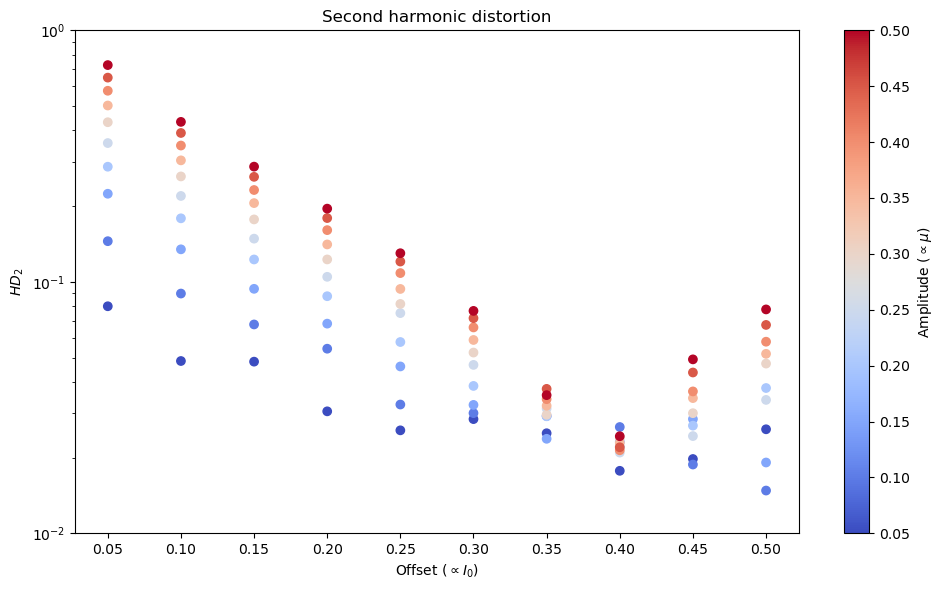

In [57]:
amps = hd2_list[:, 0]
offsets = hd2_list[:, 1]
snr_diffs = hd2_list[:, 2]

offset_list = sorted(set(offsets))

plt.figure(figsize=(10, 6))

# Plota todos os pontos de uma vez. 
# O parâmetro 'c' define a cor baseada no valor, e 'cmap' define a escala
scatter = plt.scatter(offsets, snr_diffs, c=amps, cmap='coolwarm')

plt.title("Second harmonic distortion")
plt.xlabel("Offset $(\propto I_0)$")
plt.xticks(offset_list)
# Usando 'r' antes da string (raw string) evita problemas com as barras do LaTeX no Python
plt.ylabel("$HD_2$") 
plt.ylim(0.01, 1)
plt.yticks([0.01, 1])
plt.yscale("log")

# Adiciona a barra lateral indicando a escala coolwarm
cbar = plt.colorbar(scatter)
cbar.set_label('Amplitude $(\propto \mu)$')

plt.tight_layout()
plt.show()

No gráfico acima, quanto mais abaixo os pontos estiverem menor será o SH em relação ao fundamental. Isso é o que desejamos para o laser.
Nós estamos offset = 0.4 e amplitude de 0.5 para nossos experimentos.